## Learned, Work

model_cfg = {

            "input_dim":    train_inputs.shape[2],

            "hidden_dim":   num_neuron,

            'output_dim':   train_inputs.shape[2],

            "alpha":        0.01,

            "learn_alpha":  False,

            "preact_noise": 0.1,

            "postact_noise":0.1}

In [1]:
from rtgym import RatatouGym
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
import sys
sys.path.append('..')
from func import plt_hs

In [2]:
temp_reso, spat_reso = 100, 1 # Temp reso: 100ms; Spatial reso: 1cm
gym = RatatouGym(temporal_resolution=temp_reso, spatial_resolution=spat_reso)

gym.init_arena_map(shape="rectangle")

In [8]:
vel_mean, vel_std = 5, 2

n_channels = 100

behavior_profile = {
                    "name":                   "random_explore",
                    "type":                   "predefined",
                    "velocity_mean":          vel_mean,
                    "velocity_sd":            vel_std,
                    "random_drift_magnitude": 0.05,
                    "switch_direction_prob":  0.05,
                    "switch_velocity_prob":   0.1,
                    'avoid_boundary_dist': 60
                    }

sensory_profile = {
                   "wsm": {
                          "type":     "weak_sm_cell",
                          "n_cells":   n_channels,
                          "sigma":     15,
                          "magnitude": 4,
                          "normalize": True
                          },
                    }

# Set the sensory and behavior profiles
gym.set_sensory_from_profile(sensory_profile)
gym.set_behavior_from_profile(behavior_profile)

arena_map = gym.arena_map

<class 'rtgym.trial.trial.Trajectory'>


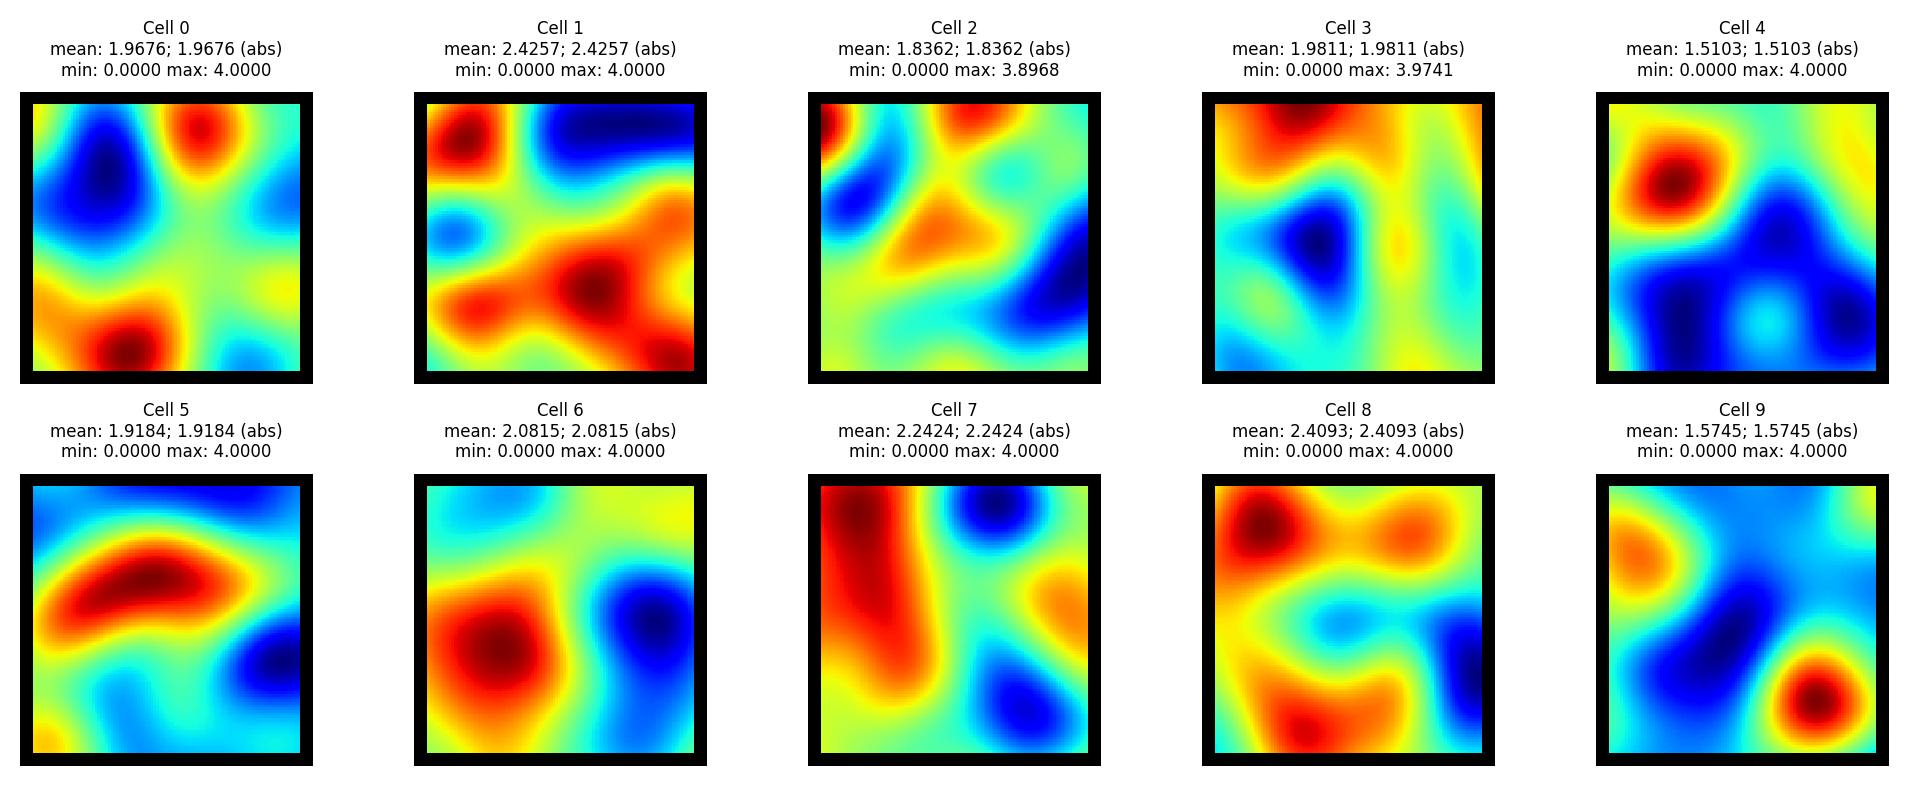

[(<Figure size 2000x800 with 10 Axes>,
  array([<Axes: title={'center': 'Cell 0\nmean: 1.9676; 1.9676 (abs)\nmin: 0.0000 max: 4.0000'}>,
         <Axes: title={'center': 'Cell 1\nmean: 2.4257; 2.4257 (abs)\nmin: 0.0000 max: 4.0000'}>,
         <Axes: title={'center': 'Cell 2\nmean: 1.8362; 1.8362 (abs)\nmin: 0.0000 max: 3.8968'}>,
         <Axes: title={'center': 'Cell 3\nmean: 1.9811; 1.9811 (abs)\nmin: 0.0000 max: 3.9741'}>,
         <Axes: title={'center': 'Cell 4\nmean: 1.5103; 1.5103 (abs)\nmin: 0.0000 max: 4.0000'}>,
         <Axes: title={'center': 'Cell 5\nmean: 1.9184; 1.9184 (abs)\nmin: 0.0000 max: 4.0000'}>,
         <Axes: title={'center': 'Cell 6\nmean: 2.0815; 2.0815 (abs)\nmin: 0.0000 max: 4.0000'}>,
         <Axes: title={'center': 'Cell 7\nmean: 2.2424; 2.2424 (abs)\nmin: 0.0000 max: 4.0000'}>,
         <Axes: title={'center': 'Cell 8\nmean: 2.4093; 2.4093 (abs)\nmin: 0.0000 max: 4.0000'}>,
         <Axes: title={'center': 'Cell 9\nmean: 1.5745; 1.5745 (abs)\nmin: 0.00

In [9]:
time_pts = 20

# Generate (Batch size) trial
gym.trial.new_trial(duration=time_pts, batch_size=2000)

gym.trial.vis_sensory()

In [10]:
space_res = gym.trial.get_responses(keys='wsm')
print('space responses:', space_res.shape)

space responses: (2000, 200, 100)


In [12]:
traj = gym.trial.get_traj()
traj['coords'] = traj['coords_float'] 
traj['hds'] = traj['head_directions']
traj['disps'] = traj['displacements']
del traj['coords_float']
del traj['head_directions']
del traj['displacements']
print(traj.keys())

dict_keys(['coords', 'hds', 'disps'])


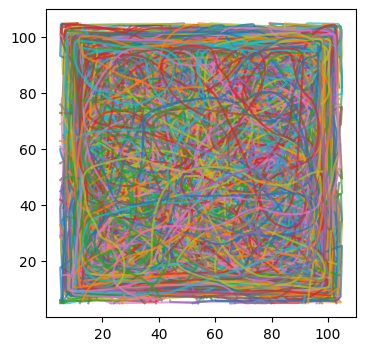

In [20]:
# Plot the sample trajectories
plt.figure(figsize=(4, 4))
for i in range(traj['coords'].shape[0]):
    plt.plot(traj['coords'][i, :, 0], traj['coords'][i, :, 1], alpha=0.7)

Text(0, 0.5, 'Channels')

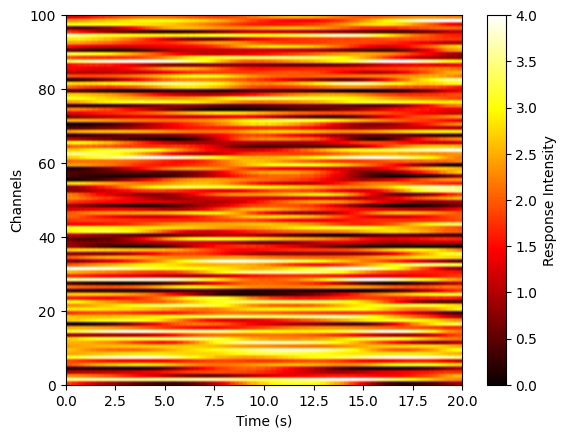

In [14]:
# Plot the space_res
plt.imshow(space_res[0].T, aspect='auto', cmap='hot', 
           extent=[0, space_res.shape[1]*temp_reso/1000, 0, n_channels])
plt.colorbar(label='Response Intensity')
plt.xlabel('Time (s)')
plt.ylabel('Channels')

In [15]:
labels = space_res.copy()

inputs = space_res.copy()
# Mask the inputs
from rtgym.utils.masking import Masking
mask = Masking(
                m_max=0.4,    # Maximum masking ratio
                m_min=0.2,    # Minimum masking ratio
                sigma_t=2.0,  # Temporal smoothing
                sigma_d=1.0,  # Spatial smoothing
                t_warmup=10,  # Number of initial time steps to remain unmasked
                # device=torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Use GPU if available
                )
inputs = mask.mask(inputs).numpy()

Text(0, 0.5, 'Channels')

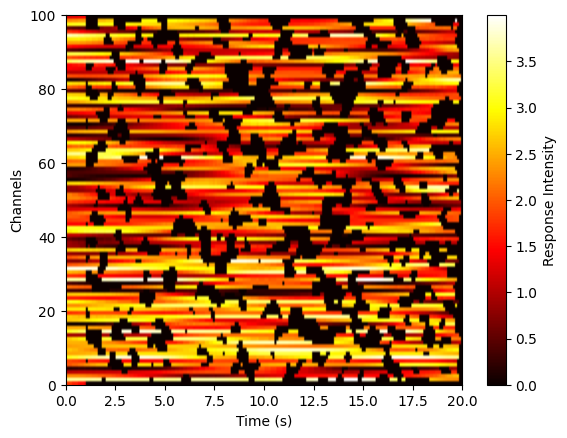

In [16]:
# Plot the masked inputs
plt.imshow(inputs[0].T, aspect='auto', cmap='hot', 
           extent=[0, inputs.shape[1]*temp_reso/1000, 0, n_channels])
plt.colorbar(label='Response Intensity')
plt.xlabel('Time (s)')
plt.ylabel('Channels')

In [17]:
# Split the data to training and test set along axis=1
from torch.utils.data import DataLoader, TensorDataset
import torch
import nn4n

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


indices = np.arange(inputs.shape[0])
train_inputs, test_inputs, train_labels, test_labels, train_indices, \
test_indices = train_test_split(inputs, labels, indices, test_size=0.05, random_state=42)

if isinstance(train_inputs, np.ndarray):
    train_inputs  = torch.from_numpy(train_inputs).float().to(device)
    train_labels  = torch.from_numpy(train_labels).float().to(device)
    test_inputs   = torch.from_numpy(test_inputs).float().to(device)
    test_labels   = torch.from_numpy(test_labels).float().to(device)

print('train_inputs:',  train_inputs.shape)
print('train_labels:',  train_labels.shape)
print('test_inputs:',   test_inputs.shape)
print('test_labels:',   test_labels.shape)
print('train_indices:', train_indices.shape)
print('test_indices:',  test_indices.shape)

train_dataset = TensorDataset(train_inputs, train_labels)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

Using device: cuda
train_inputs: torch.Size([1900, 200, 100])
train_labels: torch.Size([1900, 200, 100])
test_inputs: torch.Size([100, 200, 100])
test_labels: torch.Size([100, 200, 100])
train_indices: (1900,)
test_indices: (100,)


In [21]:
num_neuron = 512

model_cfg = {
            "input_dim":    train_inputs.shape[2],
            "hidden_dim":   num_neuron,
            'output_dim':   train_inputs.shape[2],
            "alpha":        0.01,
            "learn_alpha":  False,
            "preact_noise": 0.1,
            "postact_noise":0.1
            }


rnn = nn4n.nn.RNN(
      # Input laters (multiple recurrent layers)
      recurrent_layers=[# 1st recurrent layer
                        nn4n.nn.RecurrentLayer(
                        projection_layer=nn4n.nn.LinearLayer(
                                         input_dim=model_cfg["input_dim"],
                                         output_dim=model_cfg["hidden_dim"]
                                         ),
                        leaky_layer=nn4n.nn.LeakyLinearLayer(
                                    # ----------------------------------------
                                    linear_layer=nn4n.nn.LinearLayer(
                                        input_dim=model_cfg["hidden_dim"],
                                        output_dim=model_cfg["hidden_dim"]),
                                    # ----------------------------------------
                                    activation=torch.nn.ReLU(),
                                    alpha=model_cfg["alpha"],
                                    learn_alpha=model_cfg["learn_alpha"],
                                    preact_noise=model_cfg["preact_noise"],
                                    postact_noise=model_cfg["postact_noise"]
                                    )
                        )
                        # 2nd recurrent layer (None)
                        ],
      # Output layer
      readout_layer=nn4n.nn.LinearLayer(
                    input_dim=model_cfg["hidden_dim"],
                    output_dim=model_cfg["output_dim"]
                    )
      )
rnn.to(device)


def custom_loss(recon, target, firing_rates, lambda_mse, lambda_r):
    """
    Args:
        recon: [batch, time, dim] — reconstructed experience vectors (ŷ)
        target: [batch, time, dim] — ground truth experience vectors (y)
        firing_rates: [batch, time, N] — firing rates of all hidden neurons
    """

    # Shape values
    B, T, D = target.shape
    N = firing_rates[0].shape[2]

    # 1. Reconstruction MSE Loss
    mse = torch.sum((recon - target) ** 2) / (B * T * D)
    # mse = torch.nn.MSELoss()
    # mse = mse(recon, target)

    # 2. Firing rate regularization term
    reg = torch.sum(torch.sum(firing_rates[0], axis=(0,1))**2 / (B * T)) / N

    total_loss = lambda_mse * mse + lambda_r * reg
    # print(lambda_mse * mse, lambda_r * reg)
    return total_loss, lambda_mse * mse, lambda_r * reg


optimizer = torch.optim.Adam(rnn.parameters(), lr=0.0005) 

In [22]:
from tqdm import tqdm

rnn.train()

losses = []

for epoch in tqdm(range(5000)):

    for batch_inputs, batch_labels in train_loader:
        
        optimizer.zero_grad()
        batch_outputs, batch_hidden = rnn(batch_inputs)
        
        # loss = criterion(batch_outputs, batch_labels)
        loss, loss1, loss2 = custom_loss(batch_outputs, batch_labels, batch_hidden, lambda_mse=1, lambda_r=0.0001
                           ) 
        loss.backward()
        
        optimizer.step()
        losses.append(loss.item())
        
    if epoch % 500 == 0:
        print(f'Epoch {epoch} Loss {loss.item()}')
        print(loss1, loss2)

    if  losses[-1] < 0.01 and abs(losses[-1] - losses[-50]) < 1e-4: # len(losses) > 50  :
        print("Early stopping due to convergence.")
        break
    
print("Training complete.")

  0%|          | 1/5000 [00:01<1:50:04,  1.32s/it]

Epoch 0 Loss 1.3703677654266357
tensor(1.2195, device='cuda:0', grad_fn=<MulBackward0>) tensor(0.1509, device='cuda:0', grad_fn=<MulBackward0>)


 10%|█         | 501/5000 [09:48<1:27:38,  1.17s/it]

Epoch 500 Loss 0.053565360605716705
tensor(0.0476, device='cuda:0', grad_fn=<MulBackward0>) tensor(0.0060, device='cuda:0', grad_fn=<MulBackward0>)


 20%|██        | 1001/5000 [19:35<1:17:25,  1.16s/it]

...

Epoch 4000 Loss 0.020642481744289398
tensor(0.0155, device='cuda:0', grad_fn=<MulBackward0>) tensor(0.0052, device='cuda:0', grad_fn=<MulBackward0>)


 90%|█████████ | 4501/5000 [1:27:38<09:53,  1.19s/it]

Epoch 4500 Loss 0.019934048876166344
tensor(0.0149, device='cuda:0', grad_fn=<MulBackward0>) tensor(0.0050, device='cuda:0', grad_fn=<MulBackward0>)


100%|██████████| 5000/5000 [1:37:23<00:00,  1.17s/it]

Training complete.


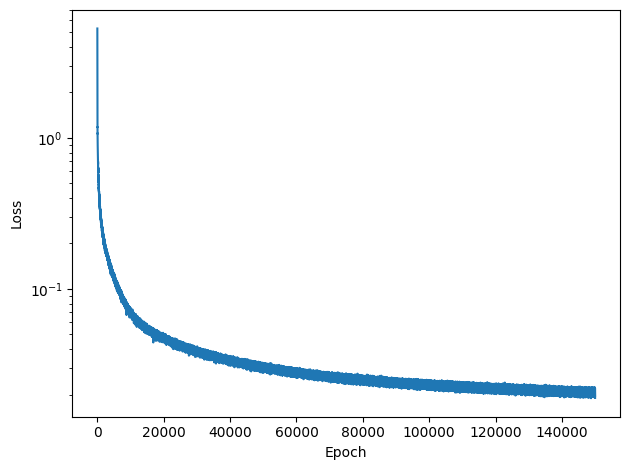

In [23]:
plt.figure()
plt.plot(losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')  
plt.tight_layout()

In [24]:
rnn.eval()
with torch.no_grad():
    test_outputs_from_RNN, hidden_states_from_RNN = rnn(test_inputs)

test_outputs = test_outputs_from_RNN.cpu().numpy()
hidden_states = hidden_states_from_RNN[0].cpu().numpy()
print('test outputs:',  type(test_outputs),  test_outputs.shape)
print('hidden states:', type(hidden_states), hidden_states.shape)

test outputs: <class 'numpy.ndarray'> (100, 200, 100)
hidden states: <class 'numpy.ndarray'> (100, 200, 512)


Text(0, 0.5, 'Channels')

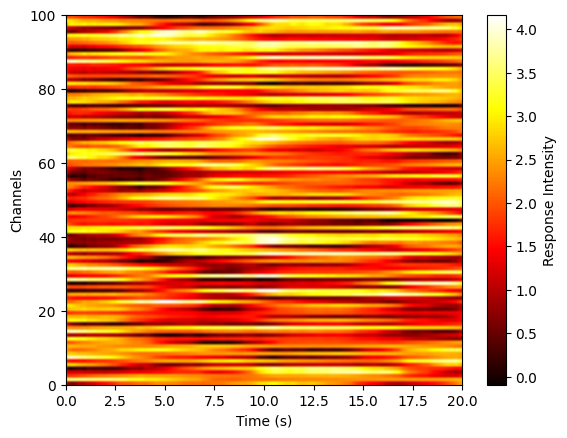

In [25]:
# Plot the masked inputs
plt.imshow(test_outputs[0].T, aspect='auto', cmap='hot', 
           extent=[0, test_outputs.shape[1]*temp_reso/1000, 0, n_channels])
plt.colorbar(label='Response Intensity')
plt.xlabel('Time (s)')
plt.ylabel('Channels')

(200, 512)
(200, 84)


Text(0.5, 0, 'Time (s)')

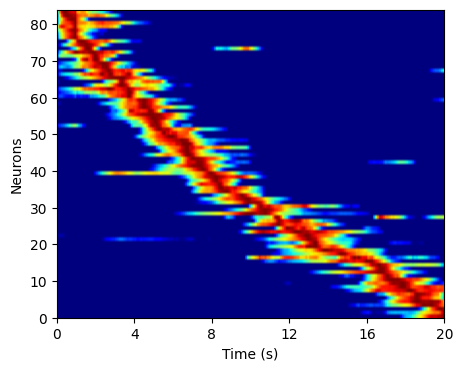

In [26]:
# Plot the single batch
avg_hs = hidden_states[0]  
print(avg_hs.shape)

fig, ax = plt.subplots(figsize=(5, 4))
norm_hs, fig, ax = plt_hs(avg_hs, min_fr=0.1, fig=fig, ax=ax)
print(norm_hs.shape)
ax.set_xlabel('Time (s)')

In [27]:
test_traj = {key: traj[key][test_indices] for key in traj.keys()}
train_traj = {key: traj[key][train_indices] for key in traj.keys()}

In [32]:
# Save the data
save_dict = {
            'train_inputs': train_inputs,
            'train_labels': train_labels,
            'test_inputs':  test_inputs,
            'test_labels':  test_labels,
            'test_outputs': test_outputs,
            'hidden_states_512': hidden_states,
            'train_traj': train_traj,
            'test_traj': test_traj,
            'arena_map': arena_map
        }
np.save('../../data/square_room_data_new.npy', save_dict)

In [33]:
# Save the model weights
torch.save(rnn.state_dict(), f'../../data/rnn_model/square_room_rnn_new.pth')